# Storm loads on parked idling wind turbine

This notebook estimates the aerodynamic loads on a horizontal-axis wind
turbine that has been shut down and *parked* during an extreme wind event.

### Work flow:
1. Pick a **design wind speed** from the 50-year return period at the site.
2. Build a **vertical wind-speed profile** (log law / power law / uniform).
3. Estimate loads:
    - **Blades:** simple lift & drag section theory, integrated along span.
    - **Tower:**  drag on a circular cylinder (Reynolds-dependent Cd).
    - **Total:**  base shear (horizontal force) and overturning moment.
4. Sweep the **blade pitch** to see why turbines *feather* in a storm.

# Students
Change the numbers in the "INPUTS" cells and re-run. 

------------------------------------

## Load modules, define constants

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [15]:
# =====================================================================
#  PHYSICAL CONSTANTS
# =====================================================================
RHO_AIR = 1.20      # air density [kg/m^3] (warm, humid hurricane air ~1.15-1.20;
                    #                        cold standard day ~1.225)
NU_AIR  = 1.5e-5    # kinematic viscosity of air [m^2/s]


## 1. Design wind speed

The annual maximum wind speed at a site is often modelled with a **Gumbel**
(Type-I extreme value) distribution:
$$F(U)=\exp\!\left(-\exp\!\left(-\frac{U-\mu}{\beta}\right)\right)$$

A return period $T$ (years) corresponds to an annual exceedance probability
$p = 1/T$, so the design speed is

$$U_T=\mu-\beta\,\ln\!\left(-\ln\!\left(1-\tfrac{1}{T}\right)\right).$$

You can (a) give the Gumbel parameters directly, (b) fit them from a record of
annual maxima, or (c) fall back on an IEC turbine-class reference speed.


In [ ]:
# Gumbel distribution
def design_wind_speed_gumbel(mu, beta, return_period=50.0):
    """50-yr-type design wind speed from Gumbel location/scale parameters."""
    return mu - beta * np.log(-np.log(1.0 - 1.0 / return_period))


def fit_gumbel_from_annual_maxima(annual_maxima):
    """Method-of-moments fit of a Gumbel distribution to a list of yearly maxima."""
    x = np.asarray(annual_maxima, float)
    s = x.std(ddof=1)
    beta = s * np.sqrt(6.0) / np.pi
    mu = x.mean() - 0.5772156649 * beta         
    return mu, beta


# IEC 61400-1 reference 10-min mean wind speed at hub height, per turbine class
IEC_CLASS_VREF = {"I": 50.0, "II": 42.5, "III": 37.5, "T": 57.0}  # [m/s] 10-min mean at hub height

In [127]:
# -------- INPUTS: choose ONE way to set the design speed -------------
# Example annual-maxima record (10-min mean at the 10 m met mast), m/s:
annual_maxima = [22, 25, 19, 28, 31, 24, 27, 35, 21, 26, 29, 33, 23, 30, 38]
mu, beta = fit_gumbel_from_annual_maxima(annual_maxima)

U10_50yr = design_wind_speed_gumbel(mu, beta, return_period=50.0)   # 10-min mean @ 10 m

# Reference height at which the design speed above is defined:
Z_REF = 100.0        # [m]  standard meteorological height
U_REF = U10_50yr    # [m/s] 10-min mean design speed at Z_REF
U_REF = IEC_CLASS_VREF["T"]  # [m/s] 10-min mean design speed at hub height

print("Gumbel fit:  mu = %.2f m/s,  beta = %.2f m/s" % (mu, beta))
print("Design 10-min mean wind speed (50-yr) at %.0f m: %.1f m/s" % (Z_REF, U10_50yr))
print("Reference wind speed at %.0f m: %.1f m/s" % (Z_REF, U_REF))




Gumbel fit:  mu = 24.98 m/s,  beta = 4.19 m/s
Design 10-min mean wind speed (50-yr) at 100 m: 41.3 m/s
Reference wind speed at 100 m: 57.0 m/s


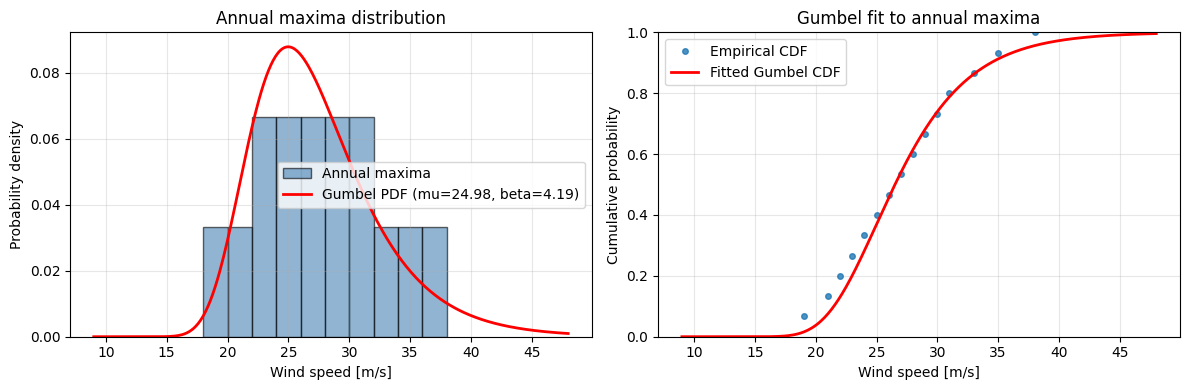

In [128]:
# Plot annual maxima distribution and fitted Gumbel distribution
x = np.asarray(annual_maxima, float)

# fitted Gumbel PDF and CDF
x_fit = np.linspace(x.min() - 10.0, x.max() + 10.0, 400)
gumbel_pdf = np.exp(-(x_fit - mu) / beta) * np.exp(-np.exp(-(x_fit - mu) / beta)) / beta
gumbel_cdf = np.exp(-np.exp(-(x_fit - mu) / beta))

# Empirical CDF for comparison
x_sorted = np.sort(x)
ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + fitted PDF
bins = np.arange(np.floor(x.min()) - 1, np.ceil(x.max()) + 2, 2)
axes[0].hist(x, bins=bins, density=True, alpha=0.6, color="steelblue", edgecolor="black", label="Annual maxima")
axes[0].plot(x_fit, gumbel_pdf, "r-", lw=2, label=f"Gumbel PDF (mu={mu:.2f}, beta={beta:.2f})")
axes[0].set_xlabel("Wind speed [m/s]")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Annual maxima distribution")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Empirical CDF + fitted CDF
axes[1].plot(x_sorted, ecdf, "o", ms=4, alpha=0.8, label="Empirical CDF")
axes[1].plot(x_fit, gumbel_cdf, "r-", lw=2, label="Fitted Gumbel CDF")
axes[1].set_xlabel("Wind speed [m/s]")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("Gumbel fit to annual maxima")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## 2. Environmental conditions for design

**Log law:**  $$U(z)=U_{ref}\,\dfrac{\ln(z/z_0)}{\ln(z_{ref}/z_0)}$$
**Power law:** $$U(z)=U_{ref}\,\left(z/z_{ref}\right)^{\alpha}$$
**Uniform:**  $$U(z)=U_{ref}$$ 

In [129]:
def U_wind_speed(z, u_ref, z_ref, model="power", z0=0.03, alpha=0.11):
    """Mean streamwise wind speed at height z. z may be a scalar or a numpy array.

    model : "log", "power" or "uniform"
    z0    : aerodynamic roughness length [m]  (sea ~2e-4, open ~0.03, suburb ~0.5)
    alpha : power-law shear exponent        (open water/terrain ~0.10-0.14)
    """
    z = np.asarray(z, float)
    if model == "log":
        return u_ref * np.log(z / z0) / np.log(z_ref / z0)
    elif model == "power":
        return u_ref * (z / z_ref) ** alpha
    elif model == "uniform":
        return np.full_like(z, u_ref, dtype=float)
    raise ValueError("model must be 'log', 'power' or 'uniform'")


def V_wind_speed(z, U_z, z_ref, model="linear",veer_rate = (40*np.pi/180)/270):
    """Mean cross-stream wind speed at height z. z may be a scalar or a numpy array.

    model : "linear" or "zero"
    z0    : aerodynamic roughness length [m]  (sea ~2e-4, open ~0.03, suburb ~0.5)
    alpha : power-law shear exponent        (open water/terrain ~0.10-0.14)
    """
    z = np.asarray(z, float)
    if model == "zero":
        return np.zeros_like(z)
    elif model == "linear":
        bb_temp = -1*veer_rate*z_ref
        return U_z*np.tan(z*veer_rate + bb_temp)
    raise ValueError("model must be 'linear' or 'zero'")


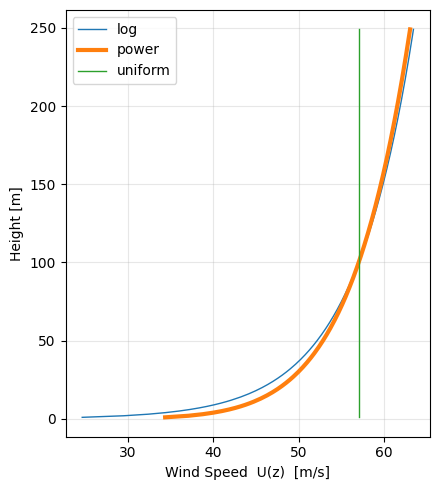

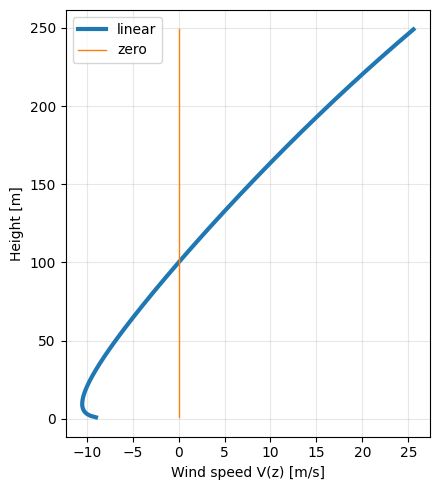

In [130]:
# -------- INPUTS: profile choice --------
PROFILE_MODEL = "power"     # "log" | "power" | "uniform"
Z0    = 0.03                # roughness length (used by log law)
ALPHA = 0.11               # shear exponent   (used by power law)
VEER_RATE = 45.0 * np.pi / 180.0 / 270.0  # rad/m, linear veer rate (used by linear model)
VEER_MODEL = "linear"     # "linear" | "zero"

# Quick look at the profile
z_plot = np.arange(1, 250, 1)
plt.figure(figsize=(4.5, 5))
for m in ("log", "power", "uniform"):
    lw=3 if m==PROFILE_MODEL else 1
    plt.plot(U_wind_speed(z_plot, U_REF, Z_REF, m, Z0, ALPHA), z_plot, label=m, linewidth=lw)
plt.xlabel("Wind Speed  U(z)  [m/s]"); 
plt.ylabel("Height [m]")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); 
plt.show()
plt.close()
#plt.savefig("turbine_fig1_profiles.png", dpi=120)
#print("saved turbine_fig1_profiles.png")

plt.figure(figsize=(4.5, 5))
for m in ("linear", "zero"):
    lw=3 if m==VEER_MODEL else 1
    plt.plot(V_wind_speed(z_plot, U_wind_speed(z_plot, U_REF, Z_REF, PROFILE_MODEL, Z0, ALPHA), Z_REF, m), z_plot, label=m, linewidth=lw)
plt.xlabel("Wind speed V(z) [m/s]"); 
plt.ylabel("Height [m]")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); 
plt.show()
plt.close()

## 3. Load calculations

In [131]:
def cl_cd_airfoil(alpha_deg,
                  cl_slope_per_deg=0.11,   # ~2*pi per rad
                  alpha_stall_deg=14.0,
                  cd0=0.012, cd2=0.02,     # drag polar Cd = cd0 + cd2*Cl^2
                  cd_max=2.0):             # flat-plate drag at 90 deg (2-D ~2.0)
    """Lift and drag coefficients of an airfoil section for |alpha| <= 90 deg."""
    a = np.asarray(alpha_deg, float)
    sign = np.sign(a)
    aa = np.abs(a)

    # --- attached-flow (linear) branch ---
    cl_lin = cl_slope_per_deg * aa
    cd_lin = cd0 + cd2 * cl_lin ** 2

    # --- Viterna post-stall branch ---
    cl_s = cl_slope_per_deg * alpha_stall_deg
    cd_s = cd0 + cd2 * cl_s ** 2
    ar = np.radians(alpha_stall_deg)
    A1 = cd_max / 2.0
    B1 = cd_max
    A2 = (cl_s - cd_max * np.sin(ar) * np.cos(ar)) * np.sin(ar) / np.cos(ar) ** 2
    B2 = (cd_s - cd_max * np.sin(ar) ** 2) / np.cos(ar)

    xr = np.radians(np.clip(aa, 1e-6, 90.0))
    s = np.maximum(np.sin(xr), 1e-6)
    cl_vit = A1 * np.sin(2 * xr) + A2 * np.cos(xr) ** 2 / s
    cd_vit = B1 * np.sin(xr) ** 2 + B2 * np.cos(xr)

    attached = aa <= alpha_stall_deg
    cl = np.where(attached, cl_lin, cl_vit) * sign
    cd = np.where(attached, cd_lin, cd_vit)
    return cl, cd


### Blade design

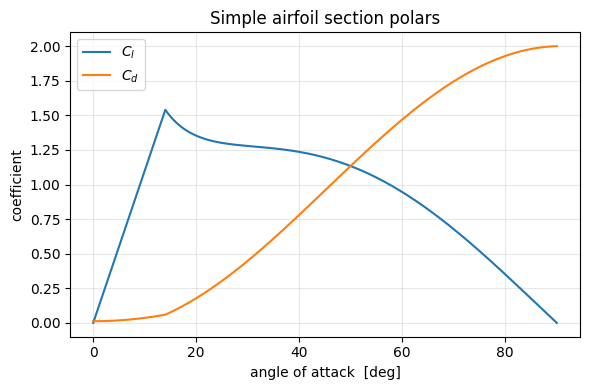

In [132]:
# Plot the coefficient curves
a_deg = np.linspace(0, 90, 181)
cl, cd = cl_cd_airfoil(a_deg)
plt.figure(figsize=(6, 4))
plt.plot(a_deg, cl, label="$C_l$")
plt.plot(a_deg, cd, label="$C_d$")
plt.xlabel("angle of attack  [deg]"); plt.ylabel("coefficient")
plt.title("Simple airfoil section polars"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); 
#plt.savefig("turbine_fig2_airfoil.png", dpi=120)
#print("saved turbine_fig2_airfoil.png")

In [133]:
# Turbine size and geomtry
R_TIP  = 60.0        # rotor (blade) tip radius [m]
R_HUB  = 1.5         # blade root radius [m]
N_BLADES = 3
HUB_HEIGHT = Z_REF    # [m]

n_sec = 40
r = np.linspace(R_HUB, R_TIP, n_sec)                    # section radii [m]
# simplified planform: chord tapers from root to tip, twist washes out to 0
chord = np.interp(r, [R_HUB, 0.25 * R_TIP, R_TIP], [3.5, 4.5, 1.3])   # [m]
twist_deg = np.interp(r, [R_HUB, R_TIP], [13.0, 0.0])                 # [deg]


### Blade loads

For each section at radius $r$ and azimuth $\psi$:

- height above ground $z = H_{hub} + r\cos\psi$ (so wind shear across the rotor disk is captured),
- relative speed $W=\sqrt{U^2+(\Omega r + V)^2}$ (set $\Omega\approx0$ for parked),
- inflow angle $\varphi=\operatorname{atan2}(U,\ \Omega r + V)$,
- local pitch $\theta=\theta_{set}+\theta_{twist}(r)$ (angle of chord to rotor plane),
- angle of attack $\alpha=\varphi-\theta$.

Section forces per unit span, projected to the rotor axis (thrust) and rotor
plane (tangential):

$$\frac{dF_n}{dr}=\tfrac12\rho W^2 c\,(C_l\cos\varphi+C_d\sin\varphi),\qquad
  \frac{dF_t}{dr}=\tfrac12\rho W^2 c\,(C_l\sin\varphi-C_d\cos\varphi).$$


In [114]:
def blade_forces(pitch_set_deg, omega_rpm=0.0,
                 profile_model=PROFILE_MODEL, veer_model=VEER_MODEL, z0=Z0, alpha_shear=ALPHA, veer_rate=VEER_RATE):
    """Total rotor thrust, in-plane force and worst blade-root bending moment.

    Sums all blades at their instantaneous azimuths (0, 120, 240 deg for 3 blades).
    Returns a dict of results plus the spanwise thrust of the most-loaded blade.
    """
    omega = omega_rpm * 2 * np.pi / 60.0        # rad/s
    theta = np.radians(pitch_set_deg + twist_deg)  # local pitch, per section

    azimuths = np.radians(np.arange(N_BLADES) * 360.0 / N_BLADES)
    thrust_total = 0.0
    tangential_total = 0.0
    thrust_blades = []
    tangential_blades = []
    root_moment_blades = []
    span_thrust_worst = None
    worst = -np.inf

    for psi in azimuths:
        z = HUB_HEIGHT + r * np.cos(psi)                 # section heights
        z = np.clip(z, 1.0, None)
        U = U_wind_speed(z, U_REF, Z_REF, profile_model, z0, alpha_shear)

        Ut = omega * r + V_wind_speed(z, U_REF, Z_REF, veer_model, veer_rate)  # tangential (rotational)
        W = np.sqrt(U ** 2 + Ut ** 2)
        phi = np.arctan2(U, np.where(Ut == 0, 1e-9, Ut)) # inflow angle [rad]
        aoa = np.degrees(phi - theta)                    # angle of attack [deg]
        aoa = np.clip(aoa, -90, 90)

        Cl, Cd = cl_cd_airfoil(aoa)
        q = 0.5 * RHO_AIR * W ** 2 * chord               # dynamic pressure * chord
        dFn = q * (Cl * np.cos(phi) + Cd * np.sin(phi))  # per-length, out-of-plane
        dFt = q * (Cl * np.sin(phi) - Cd * np.cos(phi))  # per-length, in-plane

        Fn = np.trapezoid(dFn, r)                        # thrust of this blade
        Ft = np.trapezoid(dFt, r)
        Mroot = (np.trapezoid(dFn * (r - R_HUB), r)**2 + np.trapezoid(dFt * (r - R_HUB), r)**2 )**0.5      # total root moment

        thrust_total += Fn
        tangential_total += Ft
        root_moment_blades.append(Mroot)
        thrust_blades.append(Fn)
        tangential_blades.append(Ft)
        if np.abs(np.nansum(Fn)) > worst:
            worst, span_thrust_worst = np.abs(np.nansum(Fn)), dFn.copy()

    return {
        "root_moment_blades" : root_moment_blades,
        "thrust_blades" : thrust_blades,
        "tangential_blades" : tangential_blades,
        "rotor_thrust_N": thrust_total,
        "rotor_tangential_N": tangential_total,
        "max_blade_root_moment_Nm": max(root_moment_blades),
        "span_r": r,
        "span_thrust_worst": span_thrust_worst,
    }


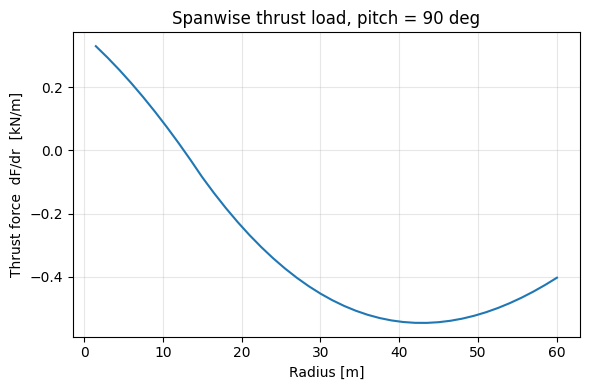

In [115]:
# -------- INPUTS: parked-rotor state --------
PITCH_SET_DEG = 90.0     # 0 deg = blade left in running position ;
                        # 90 deg = feathered .
OMEGA_RPM     = 0     # slow idling if nonzero

bl = blade_forces(PITCH_SET_DEG, OMEGA_RPM)

# spanwise load of the worst-loaded blade
plt.figure(figsize=(6, 4))
plt.plot(bl["span_r"], bl["span_thrust_worst"] / 1e3)
plt.xlabel("Radius [m]"); 
plt.ylabel("Thrust force  dF/dr  [kN/m]")
plt.title("Spanwise thrust load, pitch = %.0f deg" % PITCH_SET_DEG)
plt.grid(alpha=.3); plt.tight_layout()
# plt.savefig("turbine_fig3_spanload.png", dpi=120)
# print("saved turbine_fig3_spanload.png")


### Tower loads

Drag on a circular cylinder

$$\frac{dF}{dz}=\tfrac12\rho\,U(z)^2\,D(z)\,C_d(\mathrm{Re}),\qquad
   \mathrm{Re}=\frac{U D}{\nu}.$$
The cylinder $C_d$ drops sharply through the "drag crisis" near
$\mathrm{Re}\approx3\times10^5$ and recovers to ~0.7 at very high Re.

In [116]:
# %%
def cylinder_cd(Re):
    """Approximate drag coefficient of a smooth circular cylinder vs Reynolds no."""
    Re = np.asarray(Re, float)
    # piecewise-linear interpolation of the classic Cd(Re) curve (log-Re)
    logRe_pts = np.log10([1e3, 2e5, 5e5, 1e6, 5e6, 1e8])
    cd_pts    = np.array([1.2,  1.2,  0.35, 0.45, 0.7,  0.7])
    return np.interp(np.log10(np.clip(Re, 1e2, 1e9)), logRe_pts, cd_pts)


def tower_forces(profile_model=PROFILE_MODEL, z0=Z0, alpha_shear=ALPHA):
    """Total tower drag [N] and its contribution to the base overturning moment [N.m]."""
    z = np.linspace(1.0, HUB_HEIGHT, 200)
    D = np.interp(z, [0.0, HUB_HEIGHT], [6.0, 4.0])       # tapered tower diameter [m]
    U = U_wind_speed(z, U_REF, Z_REF, profile_model, z0, alpha_shear)
    Re = U * D / NU_AIR
    Cd = cylinder_cd(Re)
    dF = 0.5 * RHO_AIR * U ** 2 * D * Cd                   # drag per unit height
    F = np.trapezoid(dF, z)
    M = np.trapezoid(dF * z, z)                            # moment about the base
    return {"tower_drag_N": F, "tower_base_moment_Nm": M}


tw = tower_forces()

### TOTAL FORCES

Base shear (net horizontal force) and overturning moment about the tower base from rotor + tower + nacelle.

In [118]:

base_shear = (np.sum(bl["thrust_blades"]) + tw["tower_drag_N"])**2 + (np.sum(bl["tangential_blades"]))**2
overturning = ((np.sum(bl["thrust_blades"]) * HUB_HEIGHT 
               + tw["tower_base_moment_Nm"])**2 + np.sum(bl["root_moment_blades"])**2)**0.5

print("\n================  TURBINE LOAD SUMMARY  ================")
print("Design ref. wind speed (@%.0f m)   : %7.1f m/s" % (Z_REF, U_REF))
print("Wind speed at hub height (%.0f m)  : %7.1f m/s" % (HUB_HEIGHT, U_hub))
print("Blade pitch setting               : %7.1f deg" % PITCH_SET_DEG)
print("-------------------------------------------------------")
print("Rotor thrust (all blades)         : %7.1f kN" % (bl["rotor_thrust_N"] / 1e3))
print("Rotor in-plane (spin-up) force    : %7.1f kN" % (bl["rotor_tangential_N"] / 1e3))
print("Max blade-root flap moment        : %7.1f kN.m" % (bl["max_blade_root_moment_Nm"] / 1e3))
print("Tower drag                        : %7.1f kN" % (tw["tower_drag_N"] / 1e3))
print("Nacelle drag                      : %7.1f kN" % (F_nacelle / 1e3))
print("-------------------------------------------------------")
print("TOTAL base shear (horizontal)     : %7.1f GN" % (base_shear / 1e9))
print("TOTAL overturning moment @ base   : %7.1f MN.m" % (overturning / 1e6))
print("=======================================================")



================  TURBINE LOAD SUMMARY  ================
Design ref. wind speed (@100 m)   :    57.0 m/s
Wind speed at hub height (100 m)  :    57.0 m/s
Blade pitch setting               :    90.0 deg
-------------------------------------------------------
Rotor thrust (all blades)         :     6.9 kN
Rotor in-plane (spin-up) force    :  -904.5 kN
Max blade-root flap moment        : 11672.3 kN.m
Tower drag                        :   545.7 kN
Nacelle drag                      :    39.0 kN
-------------------------------------------------------
TOTAL base shear (horizontal)     :  1123.4 GN
TOTAL overturning moment @ base   :    33.3 MN.m


Minimum thrust 16.0 kN at pitch 82 deg (feathered)
Reduction vs pitch=0 deg: 99%


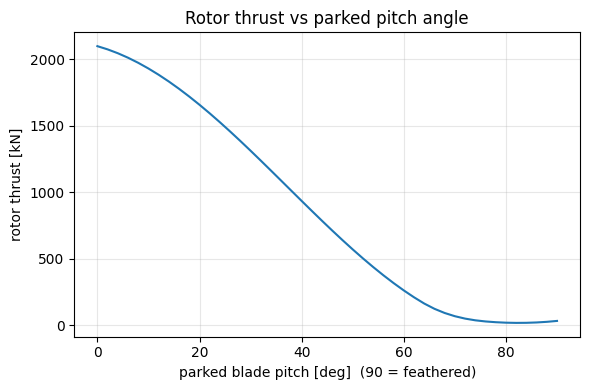

In [109]:
# %% [markdown]
# ## 6. Why turbines feather: sweep the blade pitch
#
# Hold the storm fixed and vary the parked pitch from 0 deg (blade broadside,
# fully stalled) to 90 deg (feathered, edge-on). The thrust should collapse as
# the blade is feathered — this is exactly the survival strategy real turbines use.

# %%
pitch_sweep = np.linspace(0, 90, 46)
thrust_sweep = np.array([blade_forces(p)["rotor_thrust_N"] for p in pitch_sweep])

plt.figure(figsize=(6, 4))
plt.plot(pitch_sweep, thrust_sweep / 1e3)
plt.xlabel("parked blade pitch [deg]  (90 = feathered)")
plt.ylabel("rotor thrust [kN]")
plt.title("Rotor thrust vs parked pitch angle")
plt.grid(alpha=.3); plt.tight_layout()

i_min = int(np.argmin(thrust_sweep))
print("Minimum thrust %.1f kN at pitch %.0f deg (feathered)"
      % (thrust_sweep[i_min] / 1e3, pitch_sweep[i_min]))
print("Reduction vs pitch=0 deg: %.0f%%"
      % (100 * (1 - thrust_sweep[i_min] / thrust_sweep[0])))